In [ ]:
# Jasmine Fernandez
# 09/25/2026
# Practicum 3

In [7]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import linfit as L

Problem 1a:



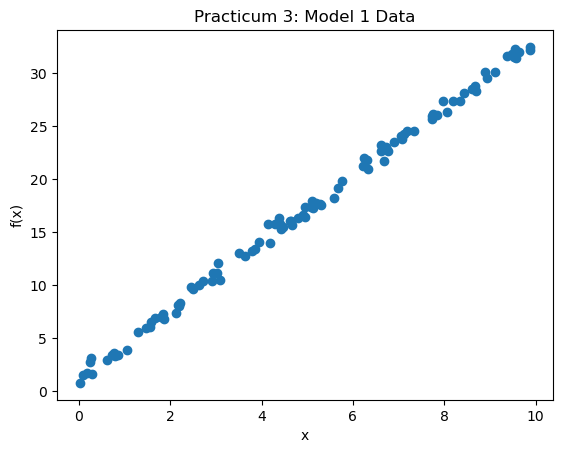

In [5]:
# Problem 1

# Part A
print("Problem 1a:\n")

# Read both data sets from the supplied file.
data = np.loadtxt("practicum3_1.dat")

# The first 100 rows contain Model 1.
x1 = data[:100, 0]
y1 = data[:100, 1]

# The last 100 rows contain Model 2.
x2 = data[100:, 0]
y2 = data[100:, 1]

# Plot the Model 1 data.
plt.figure()
plt.plot(x1, y1, "o")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Practicum 3: Model 1 Data")
plt.show()

In [11]:
# Part B
print("Problem 1b:\n")

# The uncertainty in y given in the practicum.
sigma = 0.5

# Fit Model 1 with a straight line.
(af, bf, a_unc, b_unc, chisq, prob, covar, yfit) = \
    L.linfit(y1, x1, y_unc=sigma)

# Print the fitted parameters and their uncertainties.
print("- Intercept = {0:.3f} +- {1:.3f}".format(af, a_unc))
print("- Slope     = {0:.3f} +- {1:.3f}".format(bf, b_unc))

# Compare the fitted parameters with the true parameters.
true_intercept = 1.2
true_slope = 3.2

intercept_sigma = abs(af - true_intercept) / a_unc
slope_sigma = abs(bf - true_slope) / b_unc

# Display results
print("- Intercept difference = {0:.3f} sigma".format(
    intercept_sigma))
print("- Slope difference     = {0:.3f} sigma".format(
    slope_sigma))

# The fitted intercept is 1.300 +/- 0.100, and the fitted slope is
# 3.185 +/- 0.018. The true intercept is 1.2 and the true slope is 3.2.
# The intercept differs from the true value by 0.998 sigma, and the
# slope differs by 0.865 sigma. Therefore, both fitted parameters are
# within 3 sigma of the true parameters.


# Check how the fit changes for different y uncertainties.
for sigma in [0.2, 0.9]:

    (af, bf, a_unc, b_unc, chisq, prob, covar, yfit) = \
        L.linfit(y1, x1, y_unc=sigma)

    print("\nsigma_y =", sigma)
    print("- Intercept = {0:.3f} +- {1:.3f}".format(af, a_unc))
    print("- Slope     = {0:.3f} +- {1:.3f}".format(bf, b_unc))
    
# Changing sigma_y does not change the fitted slope or intercept because
# all data points are assigned the same uncertainty. However, increasing
# sigma_y increases the uncertainties of the fitted parameters. For
# sigma_y = 0.2, the parameter uncertainties are smallest, while for
# sigma_y = 0.9, the parameter uncertainties are largest.

Problem 1b:

- Intercept = 1.300 +- 0.100
- Slope     = 3.185 +- 0.018
- Intercept difference = 0.998 sigma
- Slope difference     = 0.865 sigma

sigma_y = 0.2
- Intercept = 1.300 +- 0.040
- Slope     = 3.185 +- 0.007

sigma_y = 0.9
- Intercept = 1.300 +- 0.180
- Slope     = 3.185 +- 0.032


Problem 1c:

- Chi-squared = 83.914
- Probability = 0.844


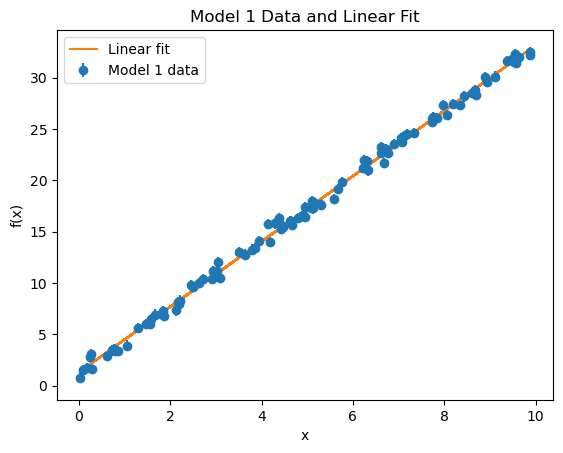

In [14]:
# Part C
print("Problem 1c:\n")

# Repeat the fit using the stated uncertainty of sigma_y = 0.5.
sigma = 0.5

(af, bf, a_unc, b_unc, chisq, prob, covar, yfit) = \
    L.linfit(y1, x1, y_unc=sigma)

# Print chi-squared and the probability of obtaining a worse fit.
print("- Chi-squared = {0:.3f}".format(chisq))
print("- Probability = {0:.3f}".format(prob))

# Plot the data and fitted linear model.
plt.figure()

plt.errorbar(x1, y1, yerr=sigma, fmt="o", label="Model 1 data")
plt.plot(x1, yfit, label="Linear fit")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Model 1 Data and Linear Fit")
plt.legend()

plt.savefig("practicum3_jfern_problem1_graph1.png")
plt.show()

# The probability is about 0.84, or 84%. This means there is about an
# 84% chance of obtaining a higher chi-squared (a worse fit) by chance
# if the data came from the fitted model with the stated random error.

Problem 1d:

- Intercept = -50.560 +- 0.100
- Slope     = 31.571 +- 0.018
- Chi-squared = 240064.442
- Probability = 0.000e+00


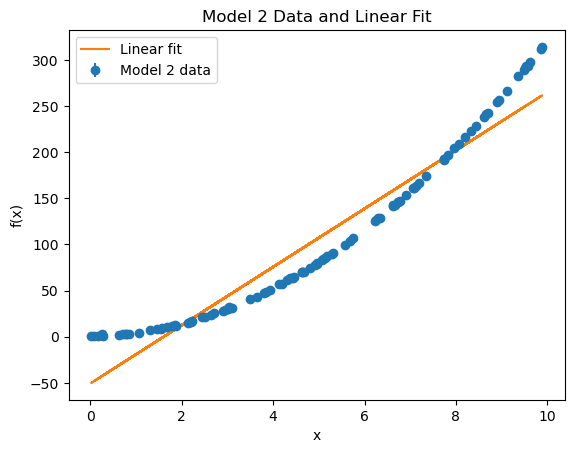

In [17]:
# Part D
print("Problem 1d:\n")

# Set the uncertainty in y to 0.5.
sigma = 0.5

# Fit a linear model to the Model 2 data.
(af, bf, a_unc, b_unc, chisq, prob, covar, yfit) = \
    L.linfit(y2, x2, y_unc=sigma)

# Print the fitted parameters.
print("- Intercept = {0:.3f} +- {1:.3f}".format(af, a_unc))
print("- Slope     = {0:.3f} +- {1:.3f}".format(bf, b_unc))
print("- Chi-squared = {0:.3f}".format(chisq))
print("- Probability = {0:.3e}".format(prob))

# Plot the Model 2 data and the linear fit.
plt.figure()

plt.errorbar(x2, y2, yerr=sigma, fmt="o", label="Model 2 data")
plt.plot(x2, yfit, label="Linear fit")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Model 2 Data and Linear Fit")
plt.legend()

plt.savefig("practicum3_jfern_problem1_graph2.png")
plt.show()

# The linear model does not fit the Model 2 data well. First, the data
# have a curved shape, while the linear model is a straight line.
# Second, the chi-squared value is extremely large (240064.442) and
# the probability is essentially zero, indicating a very poor fit.
# The data could be fit better by using a quadratic model instead.

In [19]:
# Problem 2

# Part A
print("Problem 2a:\n")

# Expected number of photons.
N = 10000.

# Generate the random samples.
poisson_data = np.random.poisson(N, 396)
uniform_data = np.random.uniform(0., 1.e6, 4)

# Combine the data to make a 400-element array.
sample = np.concatenate((poisson_data, uniform_data))

# Calculate the mean and median.
sample_mean = np.mean(sample)
sample_median = np.median(sample)

print("- Mean =", sample_mean)
print("- Median =", sample_median)

# The mean of the sample is 13392.36 and the median is 10009.0.
# The median is much closer to N = 10000. The four bad pixels can have
# very large values, which pull the mean upward. The median is less
# affected by these extreme outliers.

Problem 2a:

- Mean = 13392.364586439571
- Median = 10009.0


In [21]:
print("Problem 2b:\n")

# Calculate the standard deviation of the original sample.
sample_std = np.std(sample)

print("- Original standard deviation =", sample_std)

# Keep only points within 5 sigma of the median.
mask = np.abs(sample - sample_median) < 5. * sample_std
clipped_sample = sample[mask]

# Calculate statistics after sigma clipping.
clipped_mean = np.mean(clipped_sample)
clipped_median = np.median(clipped_sample)
clipped_std = np.std(clipped_sample)

print("- Clipped mean =", clipped_mean)
print("- Clipped median =", clipped_median)
print("- Clipped standard deviation =", clipped_std)

# After sigma clipping, the mean decreased from 13392.36 to 10185.44
# and moved much closer to the expected value of N = 10000. The median
# remained at 10009.0 because it was less affected by the outliers.
# The standard deviation decreased from 40199.54 to 3489.94 because
# extreme values were removed from the sample. The clipped standard
# deviation is still relatively large because the original standard
# deviation was very large, making the 5-sigma range very wide. Some
# bad pixels can therefore remain after this single round of clipping.

Problem 2b:

- Original standard deviation = 40199.54191979067
- Clipped mean = 10185.438508350464
- Clipped median = 10009.0
- Clipped standard deviation = 3489.9421206842326
